# **Urban Cycling Route Planner**

In [3]:
from ipyleaflet import Map, Marker
from ipywidgets import Button, Output, VBox
import random
import time
import networkx as nx
import matplotlib.pyplot as plt

from data_handler import fill_data
from algorithms import dijkstra, a_star
from algorithms_networkx import convert_to_networkx, dijkstra_networkx, astar_networkx, betweenness_centrality
import data_structure as ds
from visualize import draw_route, draw_points, interactive_map
from helpers import closest_node_calculation
from benchmark import run_benchmark

In [ ]:
area = "Debrecen"
network = fill_data(area)

if network == "error":
    print("Error fetching data")
else:
    graph = convert_to_networkx(network)
    map = interactive_map(network, graph)
    map 

In [1]:
areas = [
    "IX. kerület",        # smaller district
    "XI. kerület",        # medium district
    "Budapest",           # full city
    "Amsterdam",          # larger city
]

In [ ]:
results = run_benchmark(areas, 50)

Benchmarking 1417 nodes:
Result: Dijkstra: 0.00029  A*: 0.0002  NetworkX - Dijkstra: 0.00022 NetworkX - A*: 0.00027
Benchmarking 4615 nodes:
Result: Dijkstra: 0.00153  A*: 0.00094  NetworkX - Dijkstra: 0.00142 NetworkX - A*: 0.00126
Benchmarking 27906 nodes:
Result: Dijkstra: 0.00926  A*: 0.00484  NetworkX - Dijkstra: 0.01076 NetworkX - A*: 0.00628


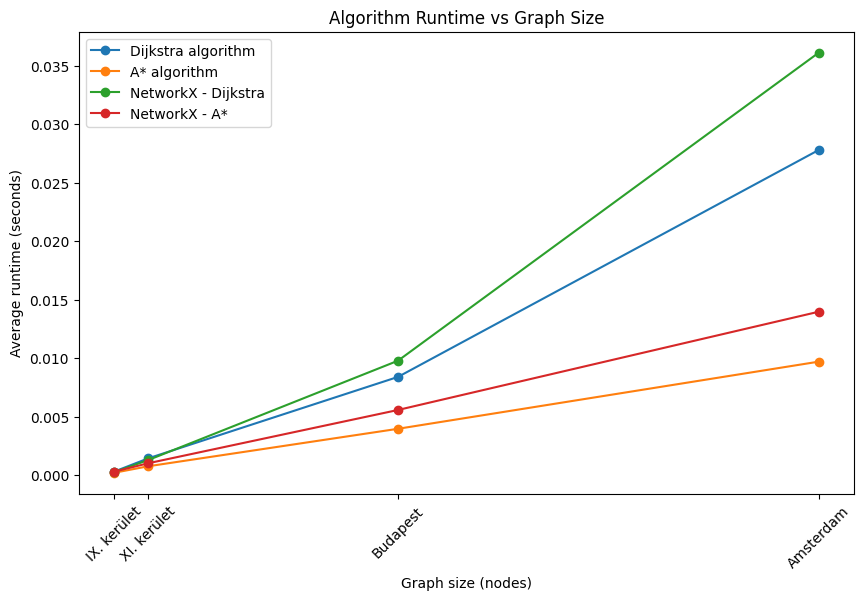

In [7]:
nodes = [r["nodes"] for r in results]
labels = [r["area"] for r in results]

plt.figure(figsize=(10, 6))

plt.plot(nodes, [r["dijkstra"] for r in results], marker='o', label="Dijkstra algorithm")
plt.plot(nodes, [r["a_star"] for r in results], marker='o', label="A* algorithm")
plt.plot(nodes, [r["networkx_dijkstra"] for r in results], marker='o', label="NetworkX - Dijkstra")
plt.plot(nodes, [r["networkx_astar"] for r in results], marker='o', label="NetworkX - A*")

plt.xticks(nodes, labels, rotation=45)
plt.xlabel("Graph size (nodes)")
plt.ylabel("Average runtime (seconds)")
plt.title("Algorithm Runtime vs Graph Size")
plt.legend()
plt.show()

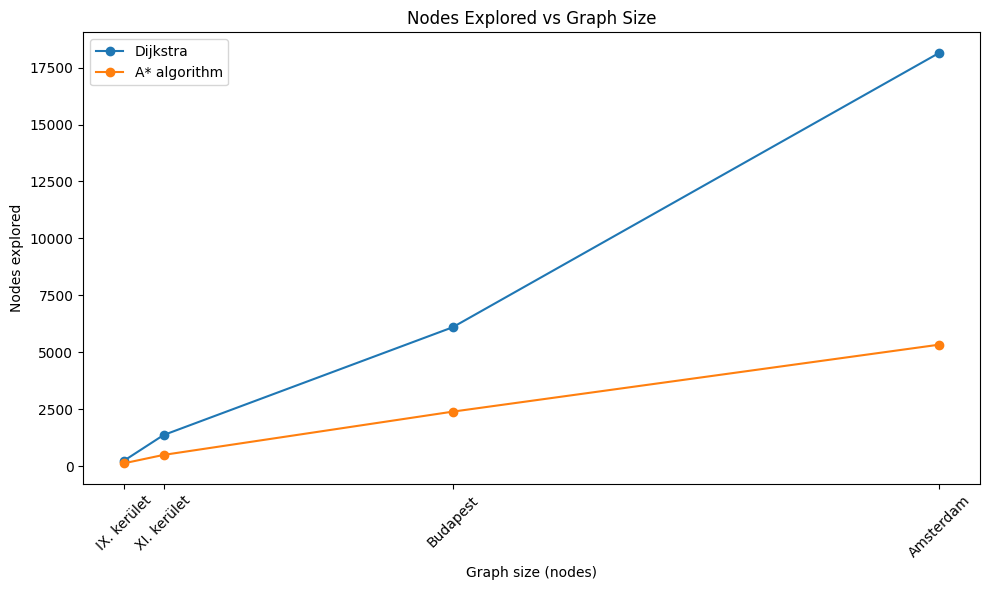

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(nodes, [r["exp_dijkstra"] for r in results], marker='o', label="Dijkstra")
plt.plot(nodes, [r["exp_astar"] for r in results], marker='o', label="A* algorithm")
plt.xlabel("Graph size (nodes)")
plt.ylabel("Nodes explored")
plt.title("Nodes Explored vs Graph Size")
plt.xticks(nodes, labels, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
network = fill_data('Budapest')

if network == "error":
    print("Error fetching data")

graph = convert_to_networkx(network)

start = 12700325860
end = 1613332399

path_dijkstra, len_dijkstra,_ = dijkstra(start, end, network)
path_astar, len_astar,_= a_star(start, end, network)
path_nxdijkstra, len_nxdijkstra = dijkstra_networkx(graph, start, end)
path_nxastar, len_nxastar = astar_networkx(graph, start, end)

print(path_dijkstra == path_astar)
print(path_nxdijkstra == path_nxastar)
print(path_nxastar == path_dijkstra)

print(len_dijkstra-len_astar)
print(len_nxastar-len_nxdijkstra)
print(len_nxastar-len_dijkstra)

True
True
True
0.0
0.0
0.0
